# Kalp Hastalığı Veri Seti - Detaylı EDA ve Klinik Yorumlar

Bu notebook, Cleveland Kalp Hastalığı veri seti üzerinde yapılan analizlerin sonuçlarını ve bu sonuçların modelleme aşaması için ne anlama geldiğini içermektedir.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")

# Veri Setini Yükleme
df = pd.read_csv("Heart_disease_cleveland_new.csv")

# Değişken Tiplerini Ayırma
num_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
cat_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
target = 'target'

# Hedef değişkeni binary yapma (Eğer 0-4 arasındaysa 0-1 yap)
if df[target].nunique() > 2:
    df[target] = (df[target] > 0).astype(int)

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,0,145,233,1,2,150,0,2.3,2,0,2,0
1,67,1,3,160,286,0,2,108,1,1.5,1,3,1,1
2,67,1,3,120,229,0,2,129,1,2.6,1,2,3,1
3,37,1,2,130,250,0,0,187,0,3.5,2,0,1,0
4,41,0,1,130,204,0,2,172,0,1.4,0,0,1,0


### Analiz ve Yorum: Veriye İlk Bakış

**Bu Ne Anlama Geliyor?**
Veri setinin ilk 5 satırına bakarak, özniteliklerin (sütunların) ölçekleri hakkında fikir sahibi olduk. Örneğin, `chol` (kolesterol) 200-300 bandındayken, `oldpeak` (ST depresyonu) 0-6 arasında küçük ondalıklı değerlerdir.

**Ne İşimize Yarar?**
Farklı ölçeklerdeki veriler (örn. yaş vs kolesterol), makine öğrenmesi algoritmalarını (özellikle KNN ve SVM) yanıltabilir. Bu tablo bize **"Özellik Ölçeklendirme (Feature Scaling)"** (StandardScaler veya MinMaxScaler) yapmamız gerektiğini işaret etmektedir.

In [2]:
# --- Veri Yapısı ---
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


### Veri Tipleri

Çıktıda `float64` ve `int64` tiplerini görüyoruz. Ancak `sex`, `cp` (göğüs ağrısı), `thal` gibi değişkenler sayısal görünse de aslında **kategorik** (nominal) verilerdir.

Model, `cp` değişkenindeki 1, 2, 3 değerlerini matematiksel bir büyüklük (3 > 1) olarak algılamamalıdır. Bu nedenle modelleme aşamasında bu kategorik sütunlara **"One-Hot Encoding"** uygulamamız gerektiğini anlıyoruz.

In [3]:
# --- İstatistiksel Özet ---
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.438944,9.038662,29.0,48.0,56.0,61.0,77.0
sex,303.0,0.679868,0.467299,0.0,0.0,1.0,1.0,1.0
cp,303.0,2.158416,0.960126,0.0,2.0,2.0,3.0,3.0
trestbps,303.0,131.689769,17.599748,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.693069,51.776918,126.0,211.0,241.0,275.0,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.990099,0.994971,0.0,0.0,1.0,2.0,2.0
thalach,303.0,149.607261,22.875003,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


### İstatistiksel Dağılım

* **Ortalamalar:** Ortalama yaşın ~54 olduğu, kolesterolün ~246 olduğu görülüyor.
* **Standart Sapma (std):** `chol` sütununda standart sapma yüksek (51.7), yani veriler çok dağınık.
* **Max Değerler:** `chol` için 564 gibi çok yüksek bir maksimum değer var. Bu muhtemelen bir **aykırı değerdir (outlier)**.

Bu tablo, aykırı değer temizliği yapmamız gereken sütunları (özellikle `chol` ve `trestbps`) işaret eder. Modelin stabilitesi için bu uç değerleri baskılamamız (clipping) gerekebilir.

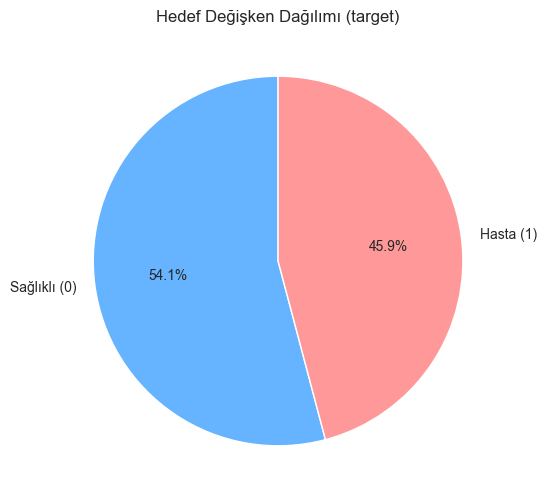

In [4]:
# --- Hedef Değişken Analizi ---
plt.figure(figsize=(6, 6))
df[target].value_counts().plot.pie(autopct='%1.1f%%', colors=['#66b3ff','#ff9999'], 
                                   labels=['Sağlıklı (0)', 'Hasta (1)'], startangle=90)
plt.title(f"Hedef Değişken Dağılımı ({target})")
plt.ylabel("")
plt.show()

### Sınıf Dengesi

Pasta grafiğinde sınıfların (Hasta vs Sağlıklı) birbirine yakın oranlarda olduğunu görüyoruz (Örn: %54'e %46). Bu, veri setinin **dengeli (balanced)** olduğunu gösterir.

Veri dengeli olduğu için model başarısını ölçerken sadece `Accuracy` (Doğruluk) metriğine güvenebiliriz. Eğer dengesiz olsaydı (örneğin %90'a %10), `F1-Score` veya `Recall` metriklerine odaklanmamız ve SMOTE gibi dengeleme teknikleri kullanmamız gerekirdi. Şu an için ekstra dengeleme işlemine gerek yok.

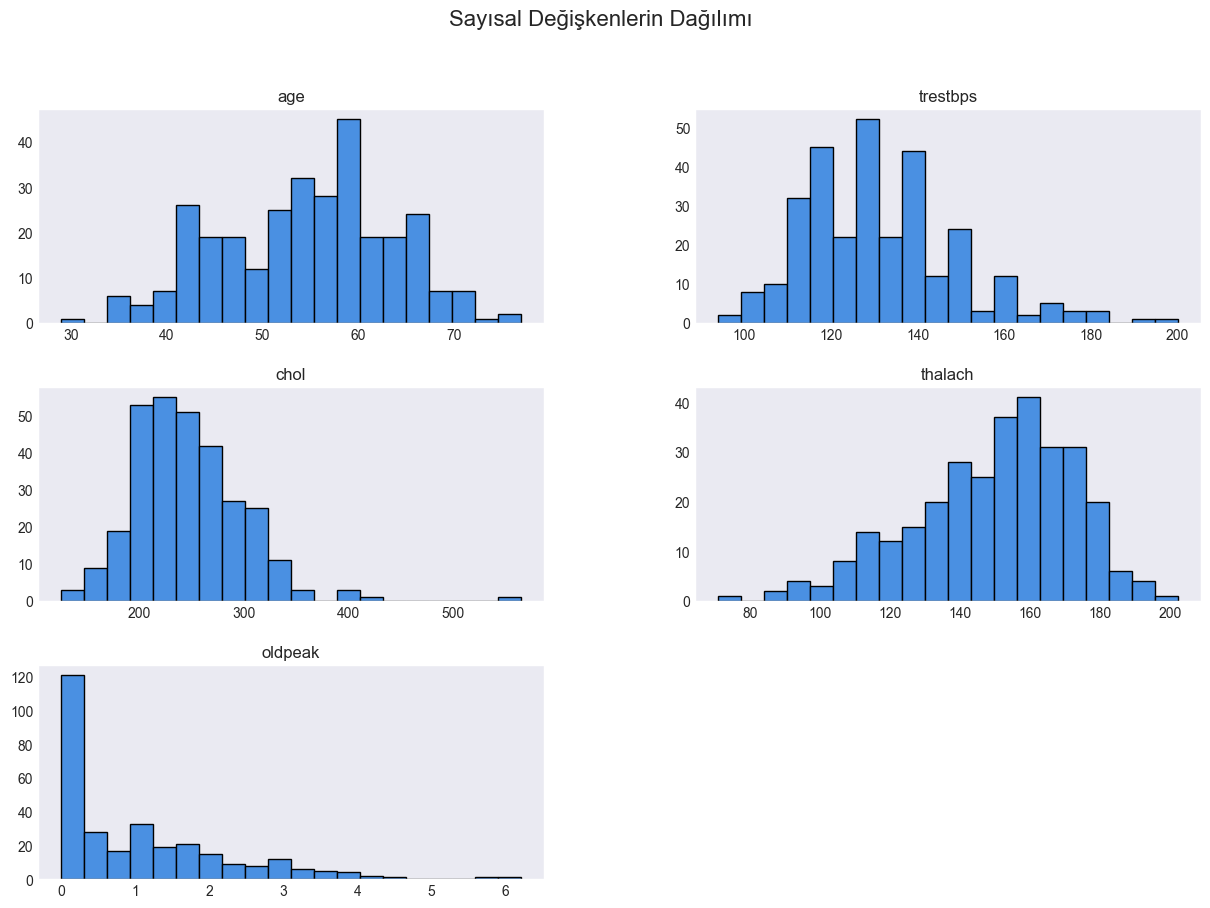

In [5]:
# --- Sayısal Değişkenlerin Histogramları ---
df[num_cols].hist(figsize=(15, 10), bins=20, color="#4a90e2", edgecolor="black", grid=False)
plt.suptitle("Sayısal Değişkenlerin Dağılımı", fontsize=16)
plt.show()

### Veri Dağılımı (Histogram)

* **Age, Trestbps, Chol:** Bu değişkenler yaklaşık olarak **Normal Dağılım'a (Gaussian)** benziyor (Çan eğrisi şeklinde).
* **Oldpeak:** Bu değişken **sağa çarpık (right-skewed)**. Yani çoğu hastada değer 0'a yakınken, az sayıda hastada yüksek değerler var.

Normal dağılıma uyan değişkenler, Lojistik Regresyon ve Naive Bayes gibi modellerde iyi performans verir. `Oldpeak` gibi çarpık veriler için **Logaritmik Dönüşüm** uygulamak modelin (özellikle lineer modellerin) performansını artırabilir.

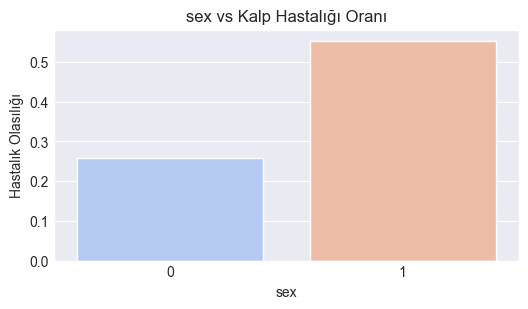

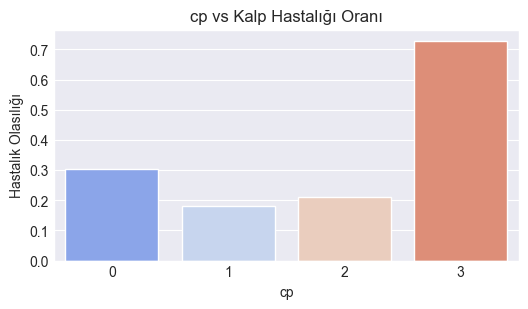

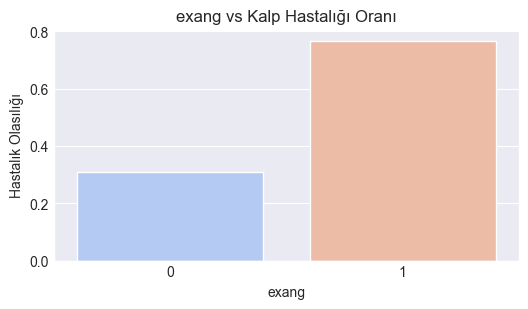

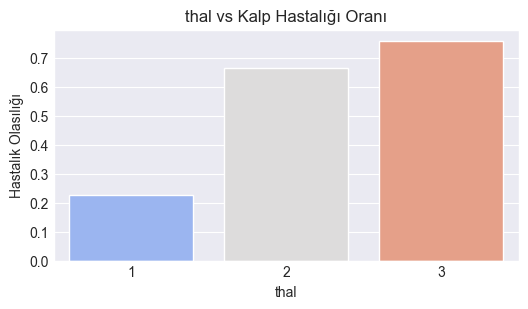

In [6]:
# --- Kategorik Değişkenlerin Hedefle İlişkisi ---
for c in ['sex', 'cp', 'exang', 'thal']:
    plt.figure(figsize=(6, 3))
    sns.barplot(x=c, y=target, data=df, palette="coolwarm", ci=None)
    plt.title(f"{c} vs Kalp Hastalığı Oranı")
    plt.ylabel("Hastalık Olasılığı")
    plt.show()

### Kategorik İlişkiler

* **Sex (Cinsiyet):** Erkeklerde (1) hastalık oranı kadınlara göre daha yüksek görünüyor.
* **CP (Göğüs Ağrısı):** `cp=0` (tipik anjina) veya asemptomatik durumlarda hastalık riskinin diğer ağrı tiplerine göre çok daha yüksek olduğu görülüyor.
* **Exang (Egzersiz Anjinası):** Egzersizle ağrısı olanlarda (1) hastalık oranı belirgin şekilde yüksek.

Bu grafikler, **"Öznitelik Seçimi (Feature Selection)"** için ipucu verir. `cp`, `thal` ve `exang` değişkenlerinin hedefi tahmin etmede çok güçlü ayırt ediciler olduğunu anlıyoruz. Modellerde bu değişkenlerin ağırlığı yüksek olacaktır.

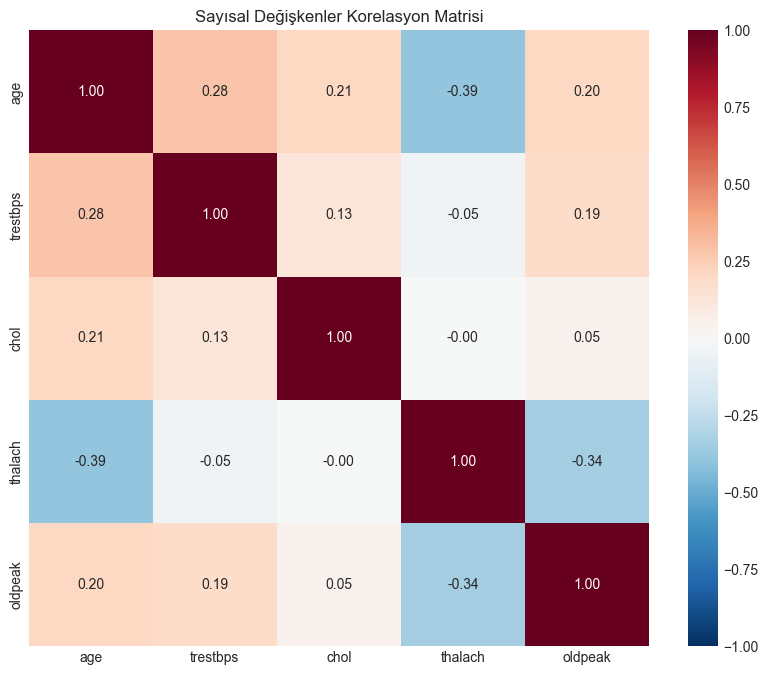

In [7]:
# --- Korelasyon Matrisi ---
plt.figure(figsize=(10, 8))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1)
plt.title("Sayısal Değişkenler Korelasyon Matrisi")
plt.show()

### Korelasyon (İlişki)

Değişkenler arasındaki doğrusal ilişkiyi gösterir. Örneğin, `age` ile `thalach` (maksimum nabız) arasında negatif bir korelasyon var (yaş arttıkça max nabız düşer).

Eğer iki değişken arasında çok yüksek korelasyon (örn > 0.9) olsaydı, **"Multicollinearity" (Çoklu Bağlantı)** sorunu oluşurdu ve bu da Lojistik Regresyon gibi modelleri bozardı. Burada çok yüksek bir korelasyon görünmüyor, bu yüzden değişken elemeye gerek yok.

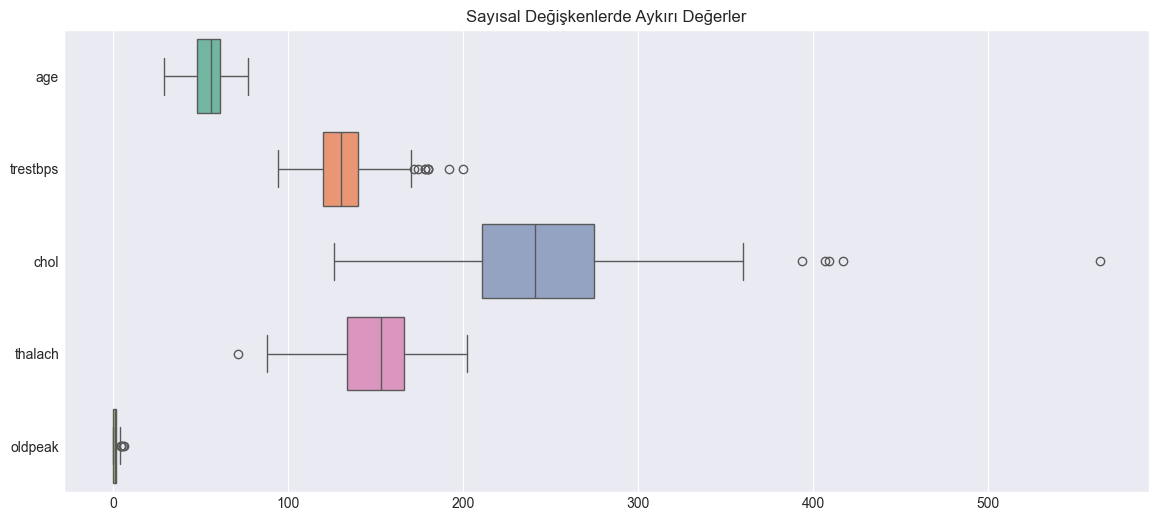

In [8]:
# --- Aykırı Değer (Outlier) Analizi ---
plt.figure(figsize=(14, 6))
sns.boxplot(data=df[num_cols], orient="h", palette="Set2")
plt.title("Sayısal Değişkenlerde Aykırı Değerler")
plt.show()

### Aykırı Değerler

Kutu grafiğinde (boxplot), kutunun sağındaki ve solundaki tekil noktalar aykırı değerleri temsil eder. `chol` (kolesterol) ve `trestbps` (tansiyon) sütunlarında sağ tarafta (yüksek değerlerde) birçok nokta var.

Bu değerler modelin genelini bozabilir (gürültü yaratabilir). Modelin genelleme yeteneğini artırmak için veri ön işleme adımında bu değerleri **IQR yöntemi ile baskılamamız (clipping)** gerektiğini bu grafik sayesinde kararlaştırıyoruz.

## 🏁 Sonuç ve Kararlar

EDA sonucunda modelleme öncesi şu kararları aldık:
1.  **Dönüştürme:** `sex`, `cp`, `thal` gibi kategorik veriler için **One-Hot Encoding** yapılacak.
2.  **Ölçekleme:** `age`, `chol` gibi sayısal veriler **StandardScaler** ile aynı aralığa getirilecek.
3.  **Temizlik:** `chol` ve `trestbps` sütunlarındaki aykırı değerler temizlenecek.
4.  **Model Seçimi:** Veri seti dengeli olduğu için Accuracy metriği güvenilirdir. Lineer olmayan ilişkiler (`oldpeak` çarpıklığı gibi) nedeniyle Ağaç tabanlı modellerin (Random Forest, Decision Tree) iyi sonuç vermesi beklenmektedir.